In [1]:
# Imports
import os
import re
import io
import zipfile
import requests
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input

In [2]:
# Parámetros
DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
MAX_VOCAB_SIZE = 10000
MAX_SEQ_LEN = 100
EMBED_DIM = 100
MODEL_PATH = 'spam_lstm_model.h5'
TOKENIZER_PATH = 'tokenizer.pkl'

In [3]:
# Descargar y cargar el dataset
r = requests.get(DATA_URL)
z = zipfile.ZipFile(io.BytesIO(r.content))
with z.open('SMSSpamCollection') as f:
    df = pd.read_csv(f, sep='	', header=None, names=['label', 'message'])
df['label_num'] = df['label'].map({'ham':0, 'spam':1})
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [4]:
# Limpieza sencilla (quita acentos y normaliza)
import unicodedata
def remove_accents(s):
    return unicodedata.normalize('NFKD', s).encode('ascii','ignore').decode('ascii')
def clean_text(text):
    text = str(text).lower()
    text = remove_accents(text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean'] = df['message'].apply(clean_text)
df.sample(5)

,label,message,label_num,clean
1742,ham,I can do that! I want to please you both insid...,0,i can do that i want to please you both inside...
3587,spam,I am hot n horny and willing I live local to y...,1,i am hot n horny and willing i live local to y...
4532,ham,I wish things were different. I wonder when i ...,0,i wish things were different i wonder when i w...
498,ham,Some of them told accenture is not confirm. Is...,0,some of them told accenture is not confirm is ...
330,ham,I'm reading the text i just sent you. Its mean...,0,i m reading the text i just sent you its meant...


In [5]:
# Tokenizer y padding (aplica oversampling si hay desbalance)
counts = df['label_num'].value_counts()
if len(counts) > 1 and counts.min() < counts.max():
    maj = df[df['label_num'] == counts.idxmax()]
    mino = df[df['label_num'] == counts.idxmin()]
    from sklearn.utils import resample
    mino_upsampled = resample(mino, replace=True, n_samples=len(maj), random_state=42)
    df_bal = pd.concat([maj, mino_upsampled]).sample(frac=1, random_state=42).reset_index(drop=True)
    print('Distribución después de upsampling:', df_bal['label_num'].value_counts().to_dict())
    use_df = df_bal
else:
    use_df = df

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(use_df['clean'].values)
sequences = tokenizer.texts_to_sequences(use_df['clean'].values)
X = pad_sequences(sequences, maxlen=MAX_SEQ_LEN, padding='post')
y = use_df['label_num'].values

# Guardar tokenizer
with open(TOKENIZER_PATH, 'wb') as f:
    pickle.dump(tokenizer, f)

X.shape, y.shape

Distribución después de upsampling: {0: 4825, 1: 4825}


((9650, 100), (9650,))

In [6]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
vocab_size

8683

In [7]:
# Construir modelo LSTM
model = Sequential([
    Input(shape=(MAX_SEQ_LEN,)),
    Embedding(vocab_size, EMBED_DIM),
    LSTM(128),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Construir explícitamente para que summary muestre shapes y parámetros
try:
    model.build((None, MAX_SEQ_LEN))
except Exception:
    pass
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │       868,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993,869 (3.79 MB)

 Trainable params: 993,869 (3.79 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Entrenamiento
from sklearn.utils import class_weight
try:
    cw = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    class_weights = {i: float(w) for i, w in enumerate(cw)}
    print('Usando class_weights:', class_weights)
except Exception:
    class_weights = None

history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1, class_weight=class_weights)

Usando class_weights: {0: 1.0025974025974025, 1: 0.9974160206718347}
Epoch 1/10


109/109 ━━━━━━━━━━━━━━━━━━━━ 28s 183ms/step - accuracy: 0.5009 - loss: 0.6935 - val_accuracy: 0.5155 - val_loss: 0.6947
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 28s 183ms/step - accuracy: 0.5009 - loss: 0.6935 - val_accuracy: 0.5155 - val_loss: 0.6947
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 23s 209ms/step - accuracy: 0.4987 - loss: 0.6938 - val_accuracy: 0.4845 - val_loss: 0.6969
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 23s 209ms/step - accuracy: 0.4987 - loss: 0.6938 - val_accuracy: 0.4845 - val_loss: 0.6969
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 29s 269ms/step - accuracy: 0.4997 - loss: 0.6936 - val_accuracy: 0.5155 - val_loss: 0.6927
Epoch 4/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 29s 269ms/step - accuracy: 0.4997 - loss: 0.6936 - val_accuracy: 0.5155 - val_loss: 0.6927
Epoch 4/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 23s 210ms/step - accuracy: 0.4921 - loss: 0.6936 - val_accuracy: 0.5155 - val_loss: 0.6930
Epoch 5/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 23s 210ms/step - accuracy: 0.4921 - loss: 0.6936 - val

In [9]:
# Evaluación
preds = (model.predict(X_test) > 0.5).astype(int).flatten()
print(classification_report(y_test, preds, target_names=['no deseado', 'spam']))
print('Accuracy:', accuracy_score(y_test, preds))

61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step
              precision    recall  f1-score   support

  no deseado       0.50      1.00      0.67       975
        spam       0.00      0.00      0.00       955

    accuracy                           0.50      1930
   macro avg       0.25      0.50      0.34      1930
weighted avg       0.26      0.50      0.34      1930

Accuracy: 0.5046632124352332
              precision    recall  f1-score   support

  no deseado       0.50      1.00      0.67       975
        spam       0.00      0.00      0.00       955

    accuracy                           0.50      1930
   macro avg       0.25      0.50      0.34      1930
weighted avg       0.26      0.50      0.34      1930

Accuracy: 0.5046632124352332


In [10]:
# Guardar modelo
model.save(MODEL_PATH)
print('Modelo guardado en', MODEL_PATH)

Modelo guardado en spam_lstm_model.h5


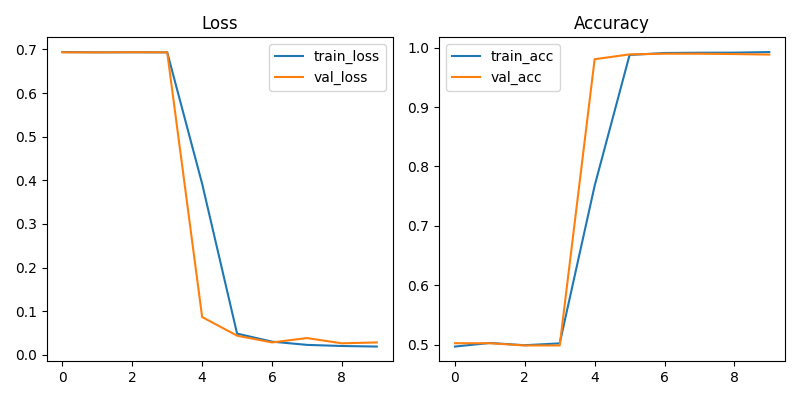

In [11]:
# Mostrar la gráfica de entrenamiento si existe (training_plot.png)
from IPython.display import Image, display
import os

plot_path = os.path.join(os.getcwd(), 'training_plot.png')
if os.path.exists(plot_path):
    display(Image(plot_path))
else:
    # Intentar generar la gráfica desde el objeto `history` si está disponible
    try:
        import matplotlib.pyplot as plt
        hist = globals().get('history', None)
        if hist is not None and hasattr(hist, 'history'):
            h = hist.history
            plt.figure(figsize=(10,4))
            plt.subplot(1,2,1)
            plt.plot(h.get('loss', []), label='loss')
            plt.plot(h.get('val_loss', []), label='val_loss')
            plt.legend(); plt.title('Loss')
            plt.subplot(1,2,2)
            acc = h.get('accuracy', []) or h.get('acc', [])
            val_acc = h.get('val_accuracy', []) or h.get('val_acc', [])
            plt.plot(acc, label='accuracy')
            plt.plot(val_acc, label='val_accuracy')
            plt.legend(); plt.title('Accuracy')
            plt.tight_layout()
            plt.savefig(plot_path)
            plt.close()
            display(Image(plot_path))
        else:
            print(f'No se encontró {plot_path}. Ejecuta el script de entrenamiento para generar la gráfica.')
    except Exception as e:
        print(f'No se encontró {plot_path} y no fue posible generar la gráfica desde history: {e}')
